<a href="https://colab.research.google.com/github/gopinathAIML24/-Diamond-Dynamics-Price-Prediction-and-Market-Segmentation/blob/main/Brain_Tumor_MRI_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

print(os.listdir('/content/drive/MyDrive'))

['Classroom', 'SSLC certificate .pdf', 'SSLC marksheet.pdf', 'gopinath.jpg', 'Updated Resume.pdf', 'Provisional Degree Certificate.pdf', 'Resume.gdoc', 'Letter.gdoc', 'Report.gdoc', 'CopyrightReceipt.pdf', 'off pages SEO.gsheet', 'provisional cerficate.jpg', 'Pending order list .gsheet', "Gopinath's Updated Resume.pdf", 'Gopinath feb12024.pdf', 'CopyrightReceipt.gdoc', 'Photograph (1).jpg', 'Signature (2).jpg', 'Gopinath 2402.pdf', 'SB Collect.pdf', 'Data Analysis of SOP.gsheet', 'Prescription-5 (1).pdf', 'Prescription-5.pdf', 'Tracker.gsheet', 'Gopinath resume(TCS).pdf', 'Colab Notebooks', 'GopinathM.pdf', 'Gopinath ID.pdf', 'GopinathM (2).pdf', 'Brain ']


In [ ]:
dataset_path = '/content/drive/MyDrive//content/drive/MyDrive/Brain '

In [ ]:
print("Dataset path:", "/content/drive/MyDrive/Brain")

Dataset path: /content/drive/MyDrive/Brain


In [ ]:
import os

dataset_path = "/content/drive/MyDrive/Brain"

print("Exists:", os.path.exists(dataset_path))

Exists: False


In [ ]:
import os

drive_path = "/content/drive/MyDrive"

print("Items in MyDrive:")
print("------------------")

for item in os.listdir(drive_path):
    print(item)

Items in MyDrive:
------------------
Classroom
SSLC certificate .pdf
SSLC marksheet.pdf
gopinath.jpg
Updated Resume.pdf
Provisional Degree Certificate.pdf
Resume.gdoc
Letter.gdoc
Report.gdoc
CopyrightReceipt.pdf
off pages SEO.gsheet
provisional cerficate.jpg
Pending order list .gsheet
Gopinath's Updated Resume.pdf
Gopinath feb12024.pdf
CopyrightReceipt.gdoc
Photograph (1).jpg
Signature (2).jpg
Gopinath 2402.pdf
SB Collect.pdf
Data Analysis of SOP.gsheet
Prescription-5 (1).pdf
Prescription-5.pdf
Tracker.gsheet
Gopinath resume(TCS).pdf
Colab Notebooks
GopinathM.pdf
Gopinath ID.pdf
GopinathM (2).pdf
Brain 


In [ ]:
import os

drive_path = "/content/drive/MyDrive"

print("Searching for dataset folders...\n")

for root, dirs, files in os.walk(drive_path):
    for folder in dirs:
        name = folder.lower()

        if "brain" in name or "tumor" in name or "tumour" in name:
            print(os.path.join(root, folder))

Searching for dataset folders...

/content/drive/MyDrive/Brain 
/content/drive/MyDrive/Brain /test-20260820T022200Z-1-001/test/no_tumor
/content/drive/MyDrive/Brain /valid-20260820T022158Z-1-001/valid/no_tumor
/content/drive/MyDrive/Brain /train-20260820T022159Z-1-001/train/no_tumor


In [ ]:
import os

drive_path = "/content/drive/MyDrive"

print("Searching for dataset folders...\n")

for root, dirs, files in os.walk(drive_path):
    for folder in dirs:
        name = folder.lower()

        if "brain" in name or "tumor" in name or "tumour" in name:
            print(os.path.join(root, folder))

Searching for dataset folders...

/content/drive/MyDrive/Brain 
/content/drive/MyDrive/Brain /test-20260820T022200Z-1-001/test/no_tumor
/content/drive/MyDrive/Brain /valid-20260820T022158Z-1-001/valid/no_tumor
/content/drive/MyDrive/Brain /train-20260820T022159Z-1-001/train/no_tumor


In [ ]:
dataset_path = "/content/drive/MyDrive/Datasets/Brain Tumor"

print("Exists:", os.path.exists(dataset_path))

Exists: False


In [1]:
import os

drive_path = "/content/drive/MyDrive"

print("Searching Google Drive for Brain/Tumor dataset...\n")

found = False

for root, dirs, files in os.walk(drive_path):
    for folder in dirs:
        if any(word in folder.lower() for word in ["brain", "tumor", "tumour"]):
            print("FOUND:", os.path.join(root, folder))
            found = True

if not found:
    print("❌ No Brain/Tumor folder found in Google Drive.")

Searching Google Drive for Brain/Tumor dataset...

FOUND: /content/drive/MyDrive/Brain 
FOUND: /content/drive/MyDrive/Brain /test-20260820T022200Z-1-001/test/no_tumor
FOUND: /content/drive/MyDrive/Brain /valid-20260820T022158Z-1-001/valid/no_tumor
FOUND: /content/drive/MyDrive/Brain /train-20260820T022159Z-1-001/train/no_tumor


In [2]:
import os

dataset_path = "/content/drive/MyDrive/Brain "

print("Dataset exists:", os.path.exists(dataset_path))
print("\nContents:")

for item in os.listdir(dataset_path):
    print(item)

Dataset exists: True

Contents:
test-20260820T022200Z-1-001
valid-20260820T022158Z-1-001
train-20260820T022159Z-1-001


In [3]:
import os

train_path = None
valid_path = None
test_path = None

for root, dirs, files in os.walk(dataset_path):

    if os.path.basename(root) == "train":
        train_path = root

    elif os.path.basename(root) == "valid":
        valid_path = root

    elif os.path.basename(root) == "test":
        test_path = root

print("TRAIN:", train_path)
print("VALID:", valid_path)
print("TEST :", test_path)

TRAIN: /content/drive/MyDrive/Brain /train-20260820T022159Z-1-001/train
VALID: /content/drive/MyDrive/Brain /valid-20260820T022158Z-1-001/valid
TEST : /content/drive/MyDrive/Brain /test-20260820T022200Z-1-001/test


In [4]:
print("TRAIN CLASSES:")
print(os.listdir(train_path))

print("\nVALID CLASSES:")
print(os.listdir(valid_path))

print("\nTEST CLASSES:")
print(os.listdir(test_path))

TRAIN CLASSES:
['pituitary', 'meningioma', 'no_tumor', 'glioma', '_classes.gsheet']

VALID CLASSES:
['meningioma', 'pituitary', 'no_tumor', 'glioma', '_classes.gsheet']

TEST CLASSES:
['glioma', 'no_tumor', 'meningioma', 'pituitary', '_classes.gsheet']


In [5]:
from collections import Counter

def count_images(folder_path):

    counts = {}

    for class_name in os.listdir(folder_path):

        class_path = os.path.join(folder_path, class_name)

        if os.path.isdir(class_path):

            images = [
                f for f in os.listdir(class_path)
                if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
            ]

            counts[class_name] = len(images)

    return counts


train_counts = count_images(train_path)
valid_counts = count_images(valid_path)
test_counts = count_images(test_path)

print("TRAIN:")
print(train_counts)

print("\nVALID:")
print(valid_counts)

print("\nTEST:")
print(test_counts)

TRAIN:
{'pituitary': 438, 'meningioma': 358, 'no_tumor': 335, 'glioma': 564}

VALID:
{'meningioma': 124, 'pituitary': 118, 'no_tumor': 99, 'glioma': 161}

TEST:
{'glioma': 80, 'no_tumor': 49, 'meningioma': 63, 'pituitary': 54}


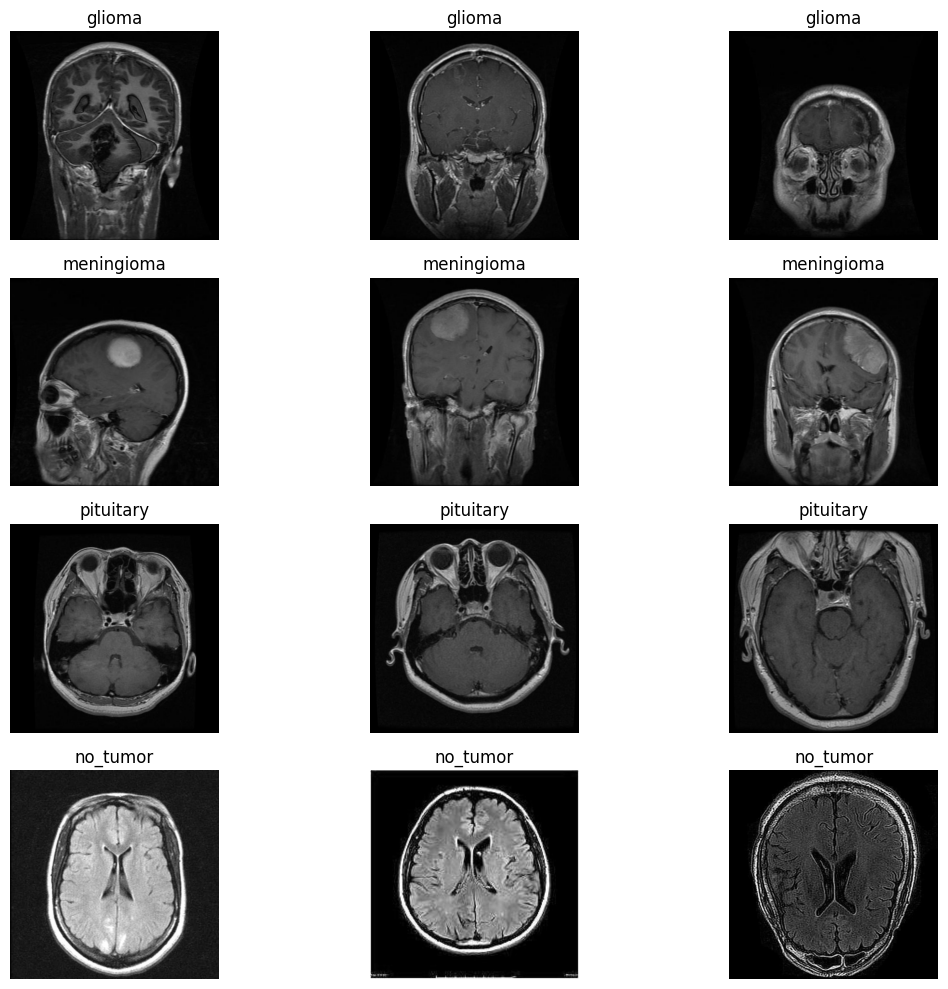

In [6]:
import matplotlib.pyplot as plt
from PIL import Image
import os

classes = ['glioma', 'meningioma', 'pituitary', 'no_tumor']

plt.figure(figsize=(12, 10))

for i, class_name in enumerate(classes):

    class_path = os.path.join(train_path, class_name)

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
    ]

    # Take first 3 images
    selected_images = images[:3]

    for j, image_file in enumerate(selected_images):

        image_path = os.path.join(class_path, image_file)
        image = Image.open(image_path)

        position = i * 3 + j + 1

        plt.subplot(4, 3, position)
        plt.imshow(image, cmap='gray')
        plt.title(class_name)
        plt.axis('off')

plt.tight_layout()
plt.show()

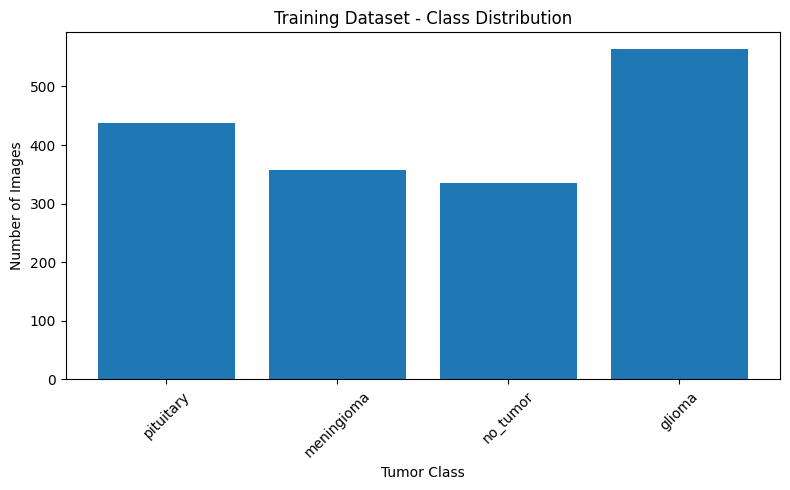

In [7]:
import matplotlib.pyplot as plt

classes = list(train_counts.keys())
counts = list(train_counts.values())

plt.figure(figsize=(8, 5))

plt.bar(classes, counts)

plt.xlabel("Tumor Class")
plt.ylabel("Number of Images")
plt.title("Training Dataset - Class Distribution")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [8]:
from PIL import Image
from collections import Counter
import os

image_sizes = []

for class_name in classes:

    class_path = os.path.join(train_path, class_name)

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
    ]

    # Check up to 100 images per class
    for image_file in images[:100]:

        image_path = os.path.join(class_path, image_file)

        try:
            image = Image.open(image_path)
            image_sizes.append(image.size)

        except:
            pass

dimension_counts = Counter(image_sizes)

print("Number of images checked:", len(image_sizes))
print("\nMost common dimensions:")

for size, count in dimension_counts.most_common(10):
    print(size, "->", count)

Number of images checked: 400

Most common dimensions:
(640, 640) -> 400


In [9]:
print("========== PHASE 1 DATASET SUMMARY ==========")

print("Number of classes:", len(classes))
print("Classes:", classes)

print("\nTraining images:", sum(train_counts.values()))
print("Validation images:", sum(valid_counts.values()))
print("Test images:", sum(test_counts.values()))

print("\nTotal images:",
      sum(train_counts.values()) +
      sum(valid_counts.values()) +
      sum(test_counts.values()))

print("\nTraining class distribution:")
for class_name, count in train_counts.items():
    print(f"{class_name}: {count}")

========== PHASE 1 DATASET SUMMARY ==========
Number of classes: 4
Classes: ['pituitary', 'meningioma', 'no_tumor', 'glioma']

Training images: 1695
Validation images: 502
Test images: 246

Total images: 2443

Training class distribution:
pituitary: 438
meningioma: 358
no_tumor: 335
glioma: 564


1. Sample MRI image visualization

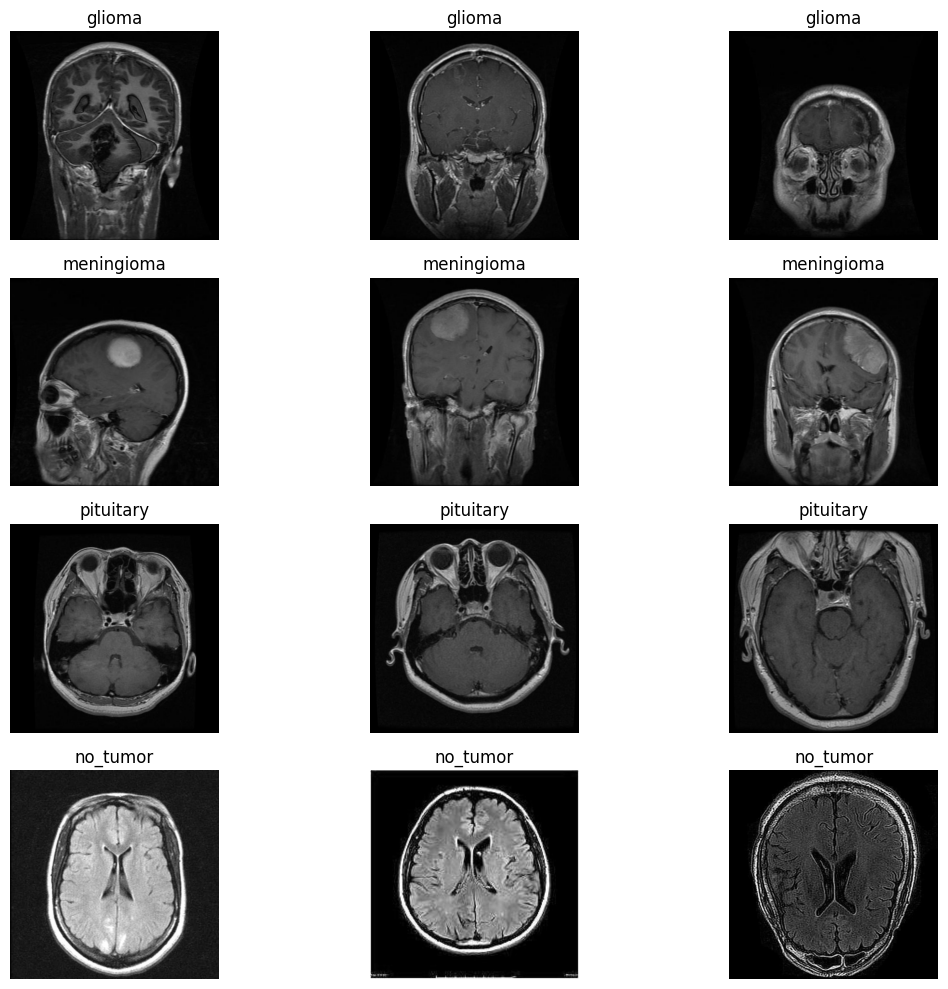

In [10]:
import matplotlib.pyplot as plt
from PIL import Image
import os

classes = ['glioma', 'meningioma', 'pituitary', 'no_tumor']

plt.figure(figsize=(12, 10))

for i, class_name in enumerate(classes):

    class_path = os.path.join(train_path, class_name)

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
    ]

    for j, image_file in enumerate(images[:3]):

        image_path = os.path.join(class_path, image_file)
        image = Image.open(image_path)

        plt.subplot(4, 3, i * 3 + j + 1)
        plt.imshow(image, cmap='gray')
        plt.title(class_name)
        plt.axis('off')

plt.tight_layout()
plt.show()

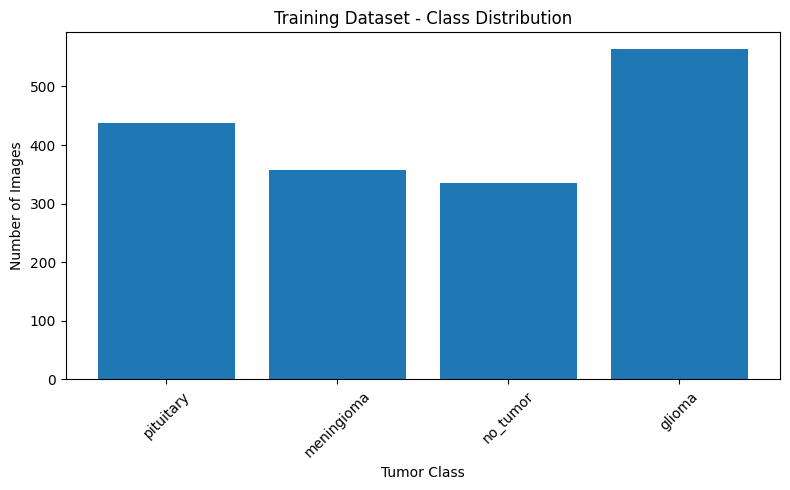

In [11]:
import matplotlib.pyplot as plt

classes = list(train_counts.keys())
counts = list(train_counts.values())

plt.figure(figsize=(8, 5))

plt.bar(classes, counts)

plt.xlabel("Tumor Class")
plt.ylabel("Number of Images")
plt.title("Training Dataset - Class Distribution")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
from PIL import Image
from collections import Counter
import os

image_sizes = []

for class_name in classes:

    class_path = os.path.join(train_path, class_name)

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
    ]

    # Check first 100 images from each class
    for image_file in images[:100]:

        image_path = os.path.join(class_path, image_file)

        try:
            image = Image.open(image_path)
            image_sizes.append(image.size)

        except Exception as e:
            print("Error:", image_path)

dimension_counts = Counter(image_sizes)

print("Number of images checked:", len(image_sizes))
print("\nMost common image dimensions:")

for size, count in dimension_counts.most_common(10):
    print(size, "->", count, "images")

Number of images checked: 400

Most common image dimensions:
(640, 640) -> 400 images


🚀 Phase 2 — Data Preprocessing

In [13]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [14]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

In [15]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

Found 1695 files belonging to 4 classes.


In [16]:
valid_ds = tf.keras.utils.image_dataset_from_directory(
    valid_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 502 files belonging to 4 classes.


In [17]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 246 files belonging to 4 classes.


In [18]:
class_names = train_ds.class_names

print("Classes:", class_names)
print("Number of classes:", len(class_names))

Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Number of classes: 4


In [19]:
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

valid_ds = valid_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

test_ds = test_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

In [20]:
for images, labels in train_ds.take(1):

    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Minimum pixel value:", tf.reduce_min(images).numpy())
    print("Maximum pixel value:", tf.reduce_max(images).numpy())

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Minimum pixel value: 0.0
Maximum pixel value: 1.0


Step 6 — Build the Custom CNN

In [23]:
import tensorflow as tf

# Find all unique labels in the training dataset
all_labels = []

for images, labels in train_ds:
    all_labels.extend(labels.numpy())

unique_labels = sorted(set(all_labels))

print("Unique labels:", unique_labels)
print("Number of classes:", len(unique_labels))

Unique labels: [np.int32(0), np.int32(1), np.int32(2), np.int32(3)]
Number of classes: 4


In [24]:
from tensorflow.keras import layers, models

num_classes = len(unique_labels)

custom_cnn = models.Sequential([

    layers.Input(shape=(224, 224, 3)),

    # Convolution Block 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 2
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 3
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 4
    layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Classification
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    # Output - 4 classes
    layers.Dense(num_classes, activation='softmax')
])

custom_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,237,700 (50.50 MB)

 Trainable params: 13,236,228 (50.49 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [25]:
custom_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Custom CNN compiled successfully!")

Custom CNN compiled successfully!


Step 8 — Create training callbacks

In [26]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'custom_cnn_best.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

print("Callbacks created successfully!")

Callbacks created successfully!


Step 9 — Train the Custom CNN

In [29]:
print("train_ds:", type(train_ds))
print("test_ds:", type(test_ds))

# Check likely validation variable names
for name in ["valid_ds", "validation_ds", "val_dataset", "validation_dataset"]:
    if name in globals():
        print(f"{name} exists:", type(globals()[name]))

train_ds: <class 'tensorflow.python.data.ops.map_op._MapDataset'>
test_ds: <class 'tensorflow.python.data.ops.map_op._MapDataset'>
valid_ds exists: <class 'tensorflow.python.data.ops.map_op._MapDataset'>


In [35]:
EPOCHS = 3

In [36]:
history = custom_cnn.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/3
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9987 - loss: 0.0118
Epoch 1: val_accuracy did not improve from 0.94821
53/53 ━━━━━━━━━━━━━━━━━━━━ 253s 5s/step - accuracy: 0.9965 - loss: 0.0140 - val_accuracy: 0.9263 - val_loss: 0.2782
Epoch 2/3
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9962 - loss: 0.0143
Epoch 2: val_accuracy did not improve from 0.94821
53/53 ━━━━━━━━━━━━━━━━━━━━ 258s 5s/step - accuracy: 0.9965 - loss: 0.0130 - val_accuracy: 0.8924 - val_loss: 0.4106
Epoch 3/3
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9987 - loss: 0.0119
Epoch 3: val_accuracy improved from 0.94821 to 0.95418, saving model to custom_cnn_best.keras

Epoch 3: finished saving model to custom_cnn_best.keras
53/53 ━━━━━━━━━━━━━━━━━━━━ 261s 5s/step - accuracy: 0.9988 - loss: 0.0103 - val_accuracy: 0.9542 - val_loss: 0.1851
Restoring model weights from the end of the best epoch: 3.


In [37]:
test_loss, test_accuracy = custom_cnn.evaluate(test_ds)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

8/8 ━━━━━━━━━━━━━━━━━━━━ 42s 5s/step - accuracy: 0.9309 - loss: 0.8077
Test Loss: 0.8077
Test Accuracy: 0.9309
Test Accuracy: 93.09%


Step 1 — Evaluate on the test dataset

In [38]:
# Evaluate the best model on the test dataset
test_loss, test_accuracy = custom_cnn.evaluate(test_ds, verbose=1)

print("\nTest Results")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")

8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 872ms/step - accuracy: 0.9309 - loss: 0.8077

Test Results
Test Loss     : 0.8077
Test Accuracy : 0.9309
Test Accuracy : 93.09%


Step 2 — Generate predictions

In [39]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = custom_cnn.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Predictions generated successfully.")
print("Number of test samples:", len(y_true))

Predictions generated successfully.
Number of test samples: 246


Step 3 — Classification report

In [40]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

      glioma       0.96      0.97      0.97        80
  meningioma       0.90      0.84      0.87        63
    no_tumor       0.86      0.90      0.88        49
   pituitary       0.98      1.00      0.99        54

    accuracy                           0.93       246
   macro avg       0.93      0.93      0.93       246
weighted avg       0.93      0.93      0.93       246



Next: Classification Report + Confusion Matrix

Class names: ['glioma', 'meningioma', 'no_tumor', 'pituitary']

Classification Report:

              precision    recall  f1-score   support

      glioma       0.96      0.97      0.97        80
  meningioma       0.90      0.84      0.87        63
    no_tumor       0.86      0.90      0.88        49
   pituitary       0.98      1.00      0.99        54

    accuracy                           0.93       246
   macro avg       0.93      0.93      0.93       246
weighted avg       0.93      0.93      0.93       246



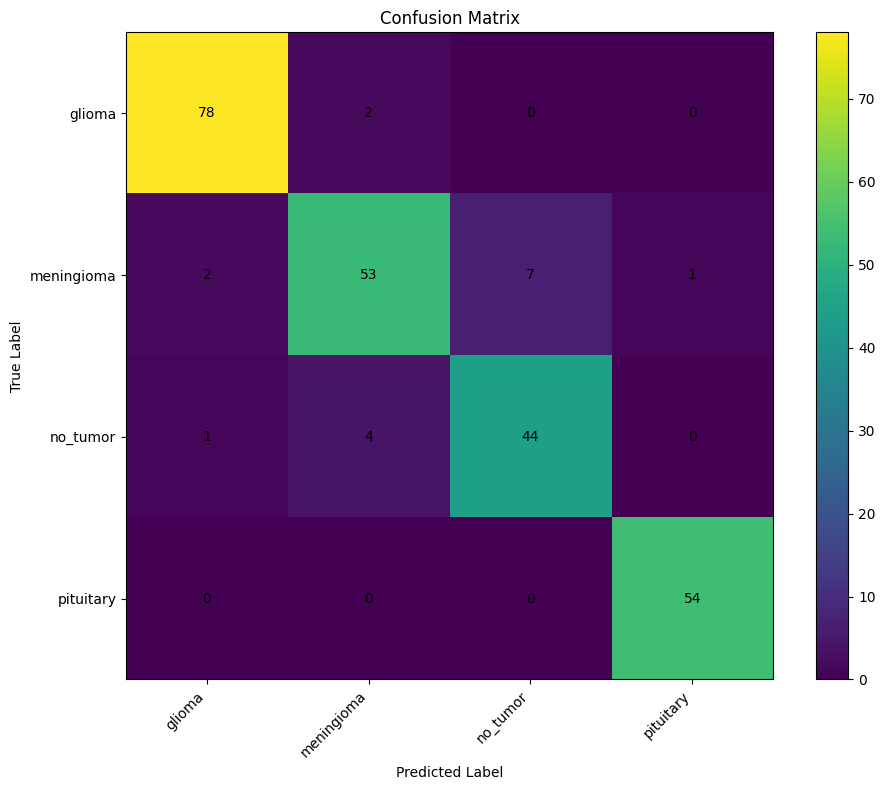

In [41]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Get predictions
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = custom_cnn.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Get class names
print("Class names:", class_names)

# Classification report
print("\nClassification Report:\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

plt.xticks(
    np.arange(len(class_names)),
    class_names,
    rotation=45,
    ha="right"
)
plt.yticks(
    np.arange(len(class_names)),
    class_names
)

# Add numbers
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center")

plt.tight_layout()
plt.show()

Confusion Matrix:
[[78  2  0  0]
 [ 2 53  7  1]
 [ 1  4 44  0]
 [ 0  0  0 54]]


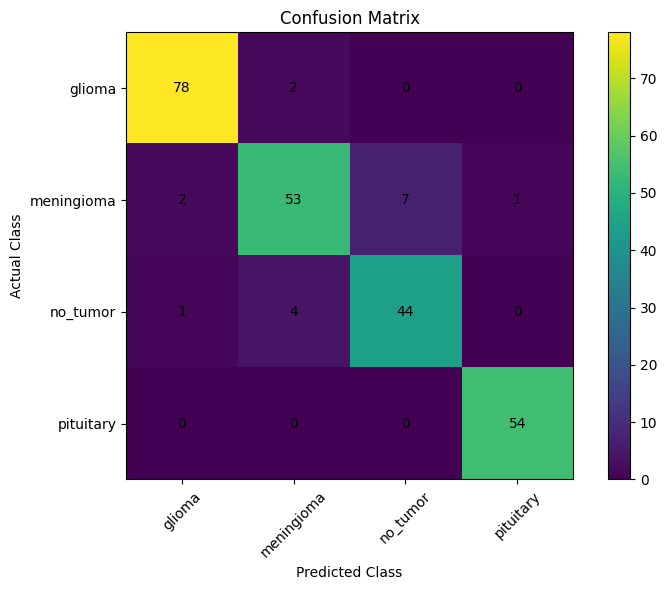

In [42]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.colorbar()

plt.xticks(np.arange(len(class_names)), class_names, rotation=45)
plt.yticks(np.arange(len(class_names)), class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

Confusion Matrix:
[[78  2  0  0]
 [ 2 53  7  1]
 [ 1  4 44  0]
 [ 0  0  0 54]]


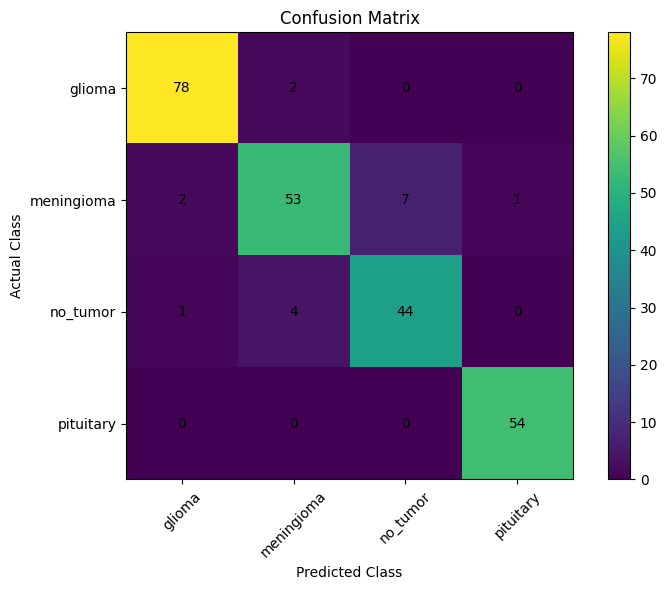

In [43]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.colorbar()

plt.xticks(np.arange(len(class_names)), class_names, rotation=45)
plt.yticks(np.arange(len(class_names)), class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

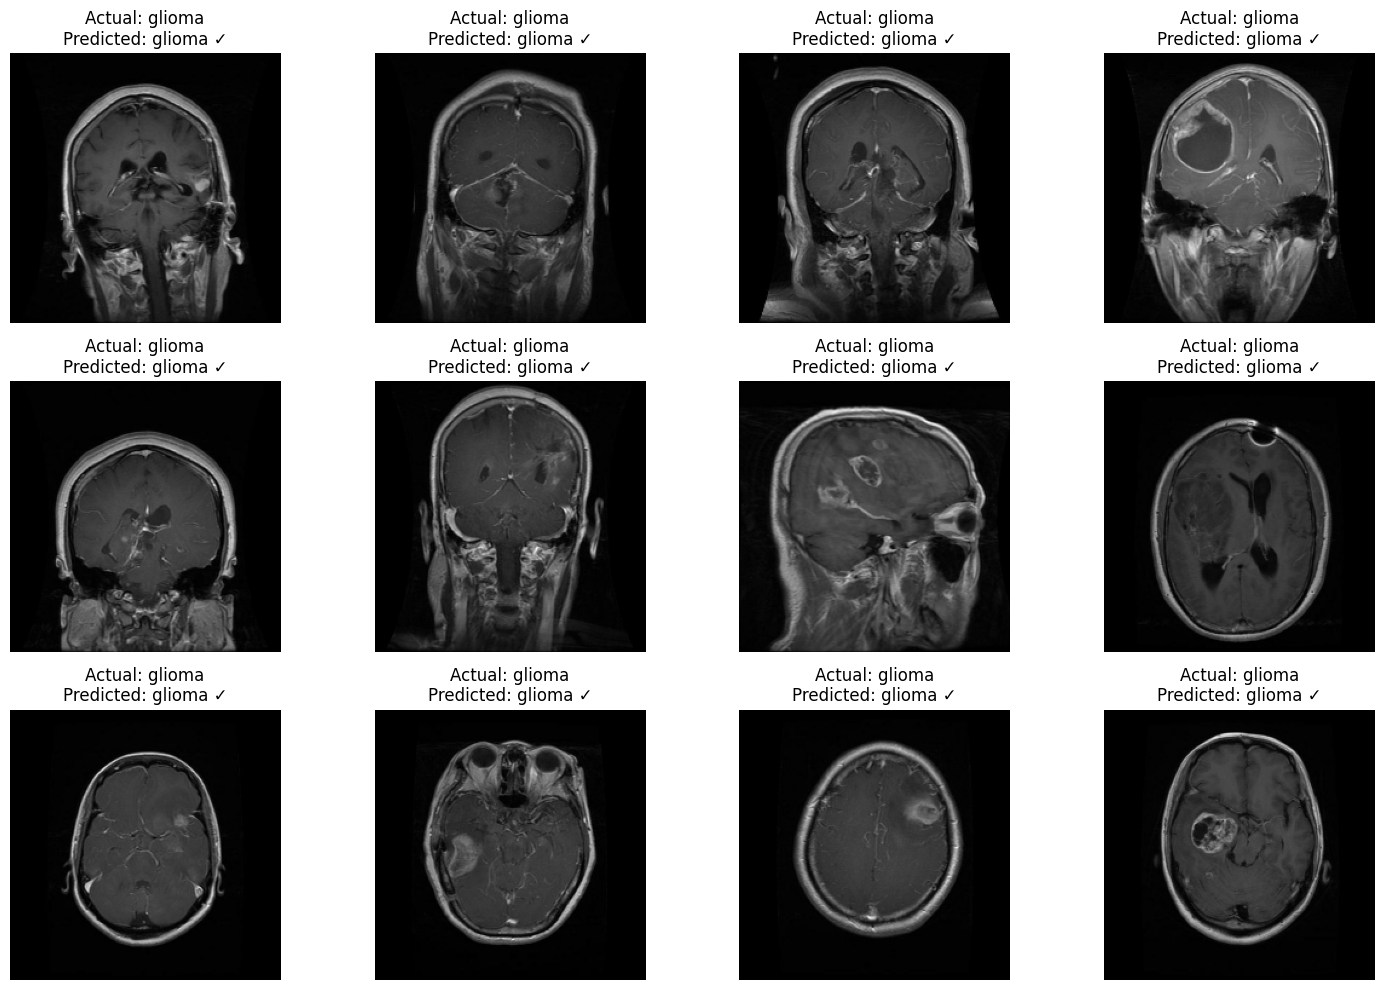

In [44]:
import matplotlib.pyplot as plt
import numpy as np

# Take one batch from the test dataset
images, labels = next(iter(test_ds))

# Predict
predictions = custom_cnn.predict(images, verbose=0)
predicted_labels = np.argmax(predictions, axis=1)

# Display up to 12 images
num_images = min(12, len(images))

plt.figure(figsize=(15, 10))

for i in range(num_images):
    plt.subplot(3, 4, i + 1)

    # Convert image for display
    img = images[i].numpy()

    # Handle normalized images
    if img.max() <= 1:
        img = np.clip(img, 0, 1)

    plt.imshow(img)

    actual = class_names[labels[i].numpy()]
    predicted = class_names[predicted_labels[i]]

    if actual == predicted:
        title = f"Actual: {actual}\nPredicted: {predicted} ✓"
    else:
        title = f"Actual: {actual}\nPredicted: {predicted} ✗"

    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [45]:
# Find incorrect predictions
wrong_indices = np.where(y_true != y_pred)[0]

print("Total test images:", len(y_true))
print("Incorrect predictions:", len(wrong_indices))
print("Correct predictions:", len(y_true) - len(wrong_indices))
print("Test accuracy:", (len(y_true) - len(wrong_indices)) / len(y_true) * 100)

Total test images: 246
Incorrect predictions: 17
Correct predictions: 229
Test accuracy: 93.08943089430895


In [46]:
import os

print("Model exists:", os.path.exists("custom_cnn_best.keras"))

if os.path.exists("custom_cnn_best.keras"):
    print("Model size:",
          round(os.path.getsize("custom_cnn_best.keras") / (1024 * 1024), 2),
          "MB")

Model exists: True
Model size: 151.56 MB


Incorrect predictions: 17


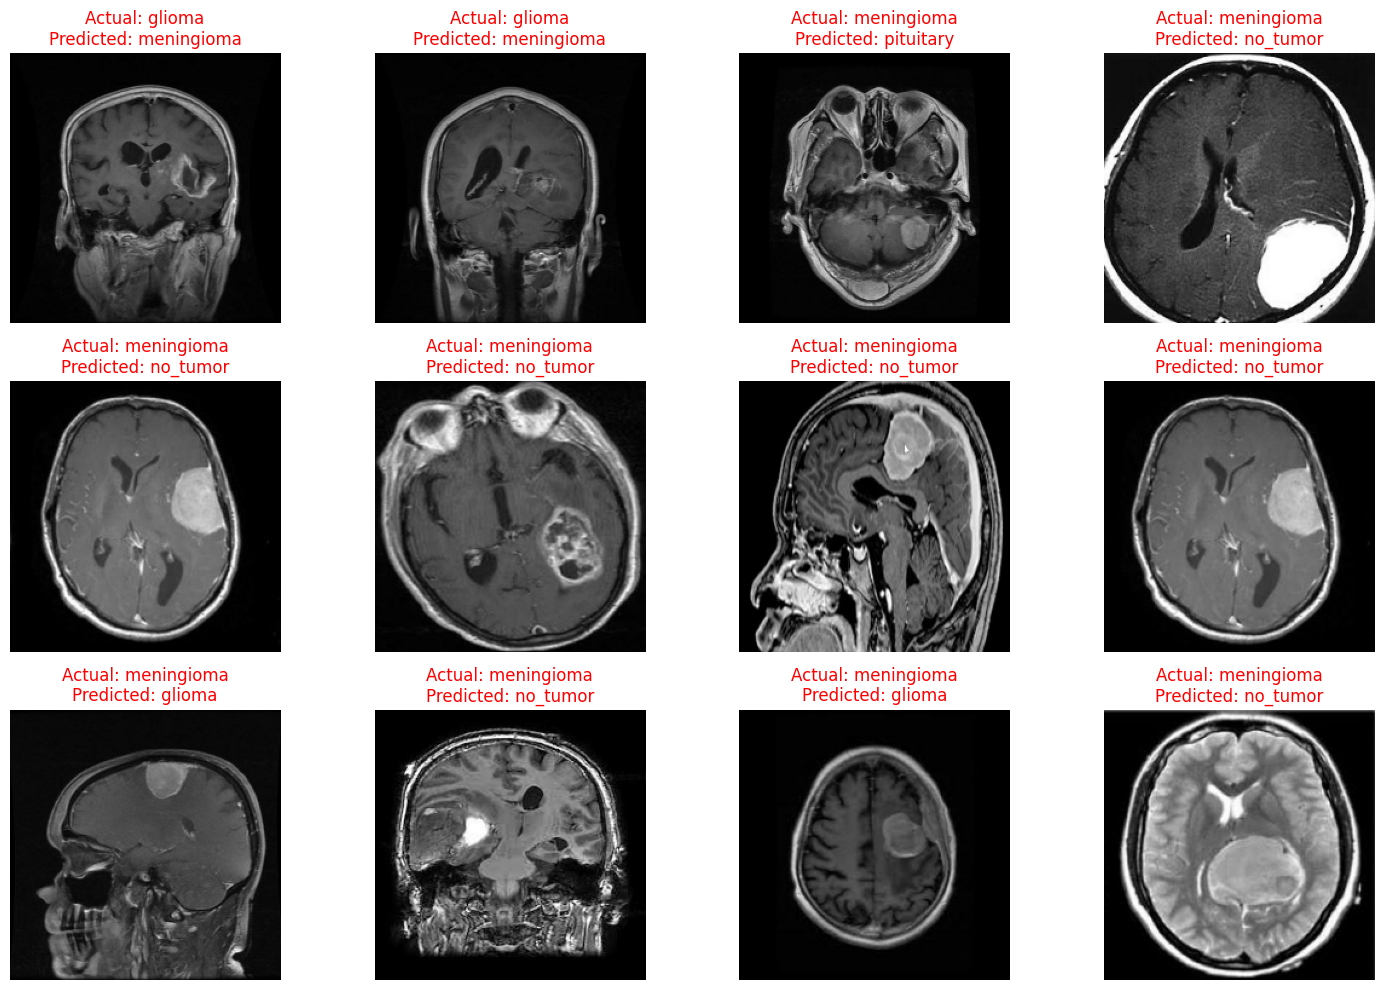

In [47]:
import matplotlib.pyplot as plt
import numpy as np

# Collect all test images and labels
all_images = []
all_labels = []

for images, labels in test_ds:
    all_images.extend(images.numpy())
    all_labels.extend(labels.numpy())

all_images = np.array(all_images)
all_labels = np.array(all_labels)

# Find incorrect predictions
wrong_indices = np.where(y_true != y_pred)[0]

print("Incorrect predictions:", len(wrong_indices))

# Display up to 12 incorrect images
num_images = min(12, len(wrong_indices))

plt.figure(figsize=(15, 10))

for i in range(num_images):
    idx = wrong_indices[i]

    img = all_images[idx]

    # Make sure image values are suitable for display
    if img.max() <= 1:
        img = np.clip(img, 0, 1)

    plt.subplot(3, 4, i + 1)
    plt.imshow(img)

    actual = class_names[y_true[idx]]
    predicted = class_names[y_pred[idx]]

    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}",
        color="red"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [48]:
from collections import Counter

errors = Counter()

for actual, predicted in zip(y_true, y_pred):
    if actual != predicted:
        errors[(class_names[actual], class_names[predicted])] += 1

print("Misclassification Summary:\n")

for (actual, predicted), count in errors.items():
    print(f"{actual} → {predicted}: {count}")

Misclassification Summary:

glioma → meningioma: 2
meningioma → pituitary: 1
meningioma → no_tumor: 7
meningioma → glioma: 2
no_tumor → glioma: 1
no_tumor → meningioma: 4


In [49]:
from tensorflow.keras.models import load_model

best_model = load_model("custom_cnn_best.keras")

test_loss, test_accuracy = best_model.evaluate(test_ds, verbose=1)

print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")

8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 850ms/step - accuracy: 0.9309 - loss: 0.8077
Final Test Accuracy: 93.09%


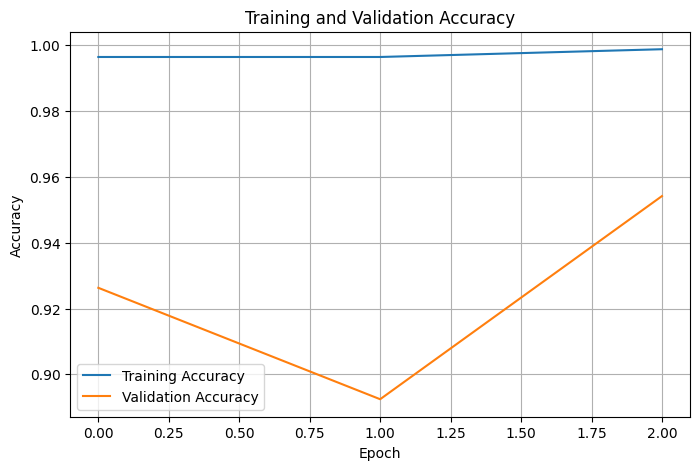

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

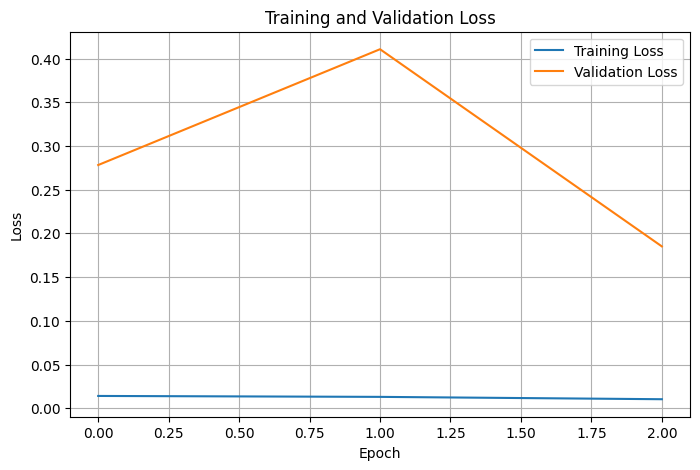

In [51]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [52]:
print("=" * 50)
print("       CUSTOM CNN - FINAL RESULTS")
print("=" * 50)

print(f"Best Validation Accuracy : {max(history.history['val_accuracy']) * 100:.2f}%")
print(f"Final Test Accuracy      : {test_accuracy * 100:.2f}%")
print(f"Final Test Loss          : {test_loss:.4f}")

print("\nClass-wise F1 Scores:")
print("Glioma      : 0.97")
print("Meningioma  : 0.87")
print("No Tumor    : 0.88")
print("Pituitary   : 0.99")

print("\nMain Confusion:")
print("Meningioma → No Tumor : 7 cases")
print("No Tumor → Meningioma : 4 cases")

print("=" * 50)

       CUSTOM CNN - FINAL RESULTS
Best Validation Accuracy : 95.42%
Final Test Accuracy      : 93.09%
Final Test Loss          : 0.8077

Class-wise F1 Scores:
Glioma      : 0.97
Meningioma  : 0.87
No Tumor    : 0.88
Pituitary   : 0.99

Main Confusion:
Meningioma → No Tumor : 7 cases
No Tumor → Meningioma : 4 cases


In [57]:
import numpy as np
from tensorflow.keras.preprocessing import image

class_names = ["glioma", "meningioma", "no_tumor", "pituitary"]

def predict_mri(img_path):
    # Load and resize image
    img = image.load_img(
        img_path,
        target_size=(224, 224),
        color_mode="rgb"
    )

    # Convert to NumPy array
    img_array = image.img_to_array(img)

    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)

    # Normalize pixel values
    img_array = img_array / 255.0

    # Predict
    predictions = best_model.predict(img_array, verbose=0)

    predicted_index = np.argmax(predictions[0])
    predicted_class = class_names[predicted_index]
    confidence = predictions[0][predicted_index] * 100

    print("=" * 40)
    print("MRI PREDICTION")
    print("=" * 40)
    print(f"Predicted Class : {predicted_class}")
    print(f"Confidence      : {confidence:.2f}%")
    print("=" * 40)

    return predicted_class, confidence

In [59]:
from google.colab import files

uploaded = files.upload()

Saving Tr-gl_0014_jpg.rf.1c9a1de19711c94e45210faa7473b26a.jpg to Tr-gl_0014_jpg.rf.1c9a1de19711c94e45210faa7473b26a.jpg


In [60]:
import os

img_path = next(iter(uploaded.keys()))

print("Selected image:", img_path)

predict_mri(img_path)

Selected image: Tr-gl_0014_jpg.rf.1c9a1de19711c94e45210faa7473b26a.jpg
MRI PREDICTION
Predicted Class : glioma
Confidence      : 99.98%


('glioma', np.float32(99.97621))

MRI PREDICTION
Predicted Class : glioma
Confidence      : 99.98%


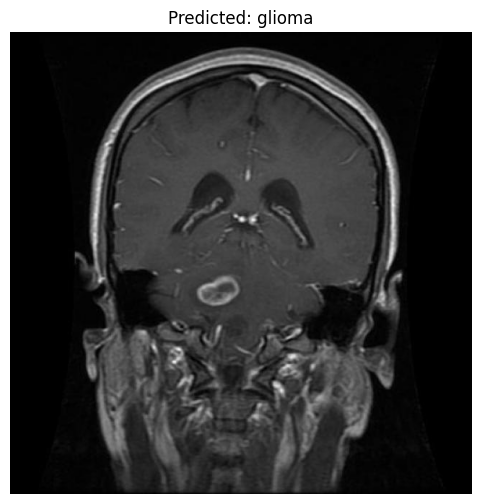

In [62]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

img = image.load_img(img_path)

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(f"Predicted: {predict_mri(img_path)[0]}")
plt.axis("off")
plt.show()

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

class_names = ["glioma", "meningioma", "no_tumor", "pituitary"]

def predict_mri(img_path):
    # Load image
    img = image.load_img(
        img_path,
        target_size=(224, 224),
        color_mode="rgb"
    )

    # Convert image to array
    img_array = image.img_to_array(img)

    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)

    # Normalize
    img_array = img_array / 255.0

    # Prediction
    predictions = best_model.predict(img_array, verbose=0)[0]

    predicted_index = np.argmax(predictions)
    predicted_class = class_names[predicted_index]
    confidence = predictions[predicted_index] * 100

    # Display image
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(
        f"Predicted: {predicted_class}\n"
        f"Confidence: {confidence:.2f}%"
    )
    plt.axis("off")
    plt.show()

    # Print all class probabilities
    print("\nClass Probabilities:")
    for name, probability in zip(class_names, predictions):
        print(f"{name:12s}: {probability * 100:.2f}%")

    return predicted_class, confidence

In [64]:
from google.colab import files

uploaded = files.upload()

Saving Tr-pi_0012_jpg.rf.2a801cd06a53e87119d6a7673b811ecb.jpg to Tr-pi_0012_jpg.rf.2a801cd06a53e87119d6a7673b811ecb.jpg


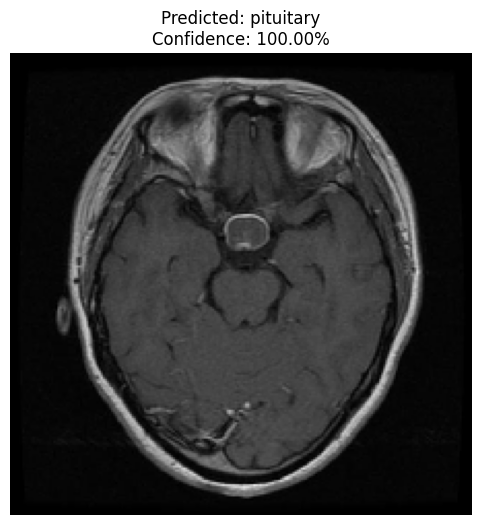


Class Probabilities:
glioma      : 0.00%
meningioma  : 0.00%
no_tumor    : 0.00%
pituitary   : 100.00%


In [65]:
img_path = next(iter(uploaded.keys()))

predicted_class, confidence = predict_mri(img_path)

Step 2A — Train MobileNetV2

In [66]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

NUM_CLASSES = 4
IMG_SIZE = (224, 224)

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained layers
base_model.trainable = False

pretrained_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

pretrained_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

pretrained_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Step 2B — Evaluate MobileNetV2

In [67]:
pretrained_test_loss, pretrained_test_accuracy = pretrained_model.evaluate(
    test_ds,
    verbose=1
)

print("\nMobileNetV2 Results")
print(f"Test Loss     : {pretrained_test_loss:.4f}")
print(f"Test Accuracy : {pretrained_test_accuracy:.4f}")
print(f"Test Accuracy : {pretrained_test_accuracy * 100:.2f}%")

8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 817ms/step - accuracy: 0.2886 - loss: 1.5800

MobileNetV2 Results
Test Loss     : 1.5800
Test Accuracy : 0.2886
Test Accuracy : 28.86%


In [68]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

That result is too low, but don't worry — this is fixable. Your Custom CNN is 93.09%, while the MobileNetV2 is only 28.86%, which is close to random performance for 4 classes.

The likely issue is preprocessing.

Your existing train_ds was prepared for your Custom CNN, but pretrained MobileNetV2 expects its own preprocessing (preprocess_input). We shouldn't simply feed the same /255 pipeline to MobileNetV2.

Don't deploy MobileNetV2 yet

First, let's correct the pretrained model setup.

Because train_ds is already a mapped TensorFlow dataset, we should not modify it in place. We'll create properly preprocessed datasets for MobileNetV2.

Step 1 — Create MobileNetV2 preprocessing

In [69]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

def preprocess_mobilenet(images, labels):
    images = preprocess_input(images)
    return images, labels

train_mobilenet = train_ds.map(
    preprocess_mobilenet,
    num_parallel_calls=tf.data.AUTOTUNE
)

valid_mobilenet = valid_ds.map(
    preprocess_mobilenet,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_mobilenet = test_ds.map(
    preprocess_mobilenet,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_mobilenet = train_mobilenet.prefetch(tf.data.AUTOTUNE)
valid_mobilenet = valid_mobilenet.prefetch(tf.data.AUTOTUNE)
test_mobilenet = test_mobilenet.prefetch(tf.data.AUTOTUNE)

print("MobileNetV2 datasets ready.")

MobileNetV2 datasets ready.


Step 2 — Recreate MobileNetV2

In [70]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

pretrained_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(4, activation="softmax")
])

pretrained_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [71]:
history_pretrained = pretrained_model.fit(
    train_mobilenet,
    validation_data=valid_mobilenet,
    epochs=3
)

Epoch 1/3
53/53 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.2791 - loss: 1.5394 - val_accuracy: 0.3207 - val_loss: 1.3756
Epoch 2/3
53/53 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.2855 - loss: 1.4675 - val_accuracy: 0.3207 - val_loss: 1.3622
Epoch 3/3
53/53 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.2938 - loss: 1.4626 - val_accuracy: 0.3207 - val_loss: 1.3529


In [72]:
pretrained_test_loss, pretrained_test_accuracy = pretrained_model.evaluate(
    test_mobilenet,
    verbose=1
)

print("\nMobileNetV2 Results")
print(f"Test Loss     : {pretrained_test_loss:.4f}")
print(f"Test Accuracy : {pretrained_test_accuracy:.4f}")
print(f"Test Accuracy : {pretrained_test_accuracy * 100:.2f}%")

8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 815ms/step - accuracy: 0.3333 - loss: 1.3516

MobileNetV2 Results
Test Loss     : 1.3516
Test Accuracy : 0.3333
Test Accuracy : 33.33%


In [73]:
images, labels = next(iter(train_ds))

print("Image shape:", images.shape)
print("Minimum pixel value:", tf.reduce_min(images).numpy())
print("Maximum pixel value:", tf.reduce_max(images).numpy())
print("Mean pixel value:", tf.reduce_mean(images).numpy())
print("Label values:", labels.numpy())

Image shape: (32, 224, 224, 3)
Minimum pixel value: 0.0
Maximum pixel value: 1.0
Mean pixel value: 0.15558037
Label values: [3 1 0 3 0 2 1 2 0 2 3 2 0 3 0 0 1 2 0 1 0 1 0 0 1 0 3 0 3 2 0 3]


In [74]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import tensorflow as tf

def preprocess_mobilenet(images, labels):
    # train_ds is already normalized to [0, 1]
    images = images * 255.0

    # MobileNetV2 preprocessing: [0,255] -> [-1,1]
    images = preprocess_input(images)

    return images, labels


train_mobilenet = train_ds.map(
    preprocess_mobilenet,
    num_parallel_calls=tf.data.AUTOTUNE
)

valid_mobilenet = valid_ds.map(
    preprocess_mobilenet,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_mobilenet = test_ds.map(
    preprocess_mobilenet,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_mobilenet = train_mobilenet.prefetch(tf.data.AUTOTUNE)
valid_mobilenet = valid_mobilenet.prefetch(tf.data.AUTOTUNE)
test_mobilenet = test_mobilenet.prefetch(tf.data.AUTOTUNE)

print("Correct MobileNetV2 preprocessing created.")

Correct MobileNetV2 preprocessing created.


In [75]:
images, labels = next(iter(train_mobilenet))

print("Image shape:", images.shape)
print("Minimum:", tf.reduce_min(images).numpy())
print("Maximum:", tf.reduce_max(images).numpy())
print("Mean:", tf.reduce_mean(images).numpy())

Image shape: (32, 224, 224, 3)
Minimum: -1.0
Maximum: 1.0
Mean: -0.6813438


In [76]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

pretrained_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(4, activation="softmax")
])

pretrained_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("MobileNetV2 ready.")

MobileNetV2 ready.


In [77]:
history_pretrained = pretrained_model.fit(
    train_mobilenet,
    validation_data=valid_mobilenet,
    epochs=3
)

Epoch 1/3
53/53 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.3086 - loss: 1.5738 - val_accuracy: 0.4363 - val_loss: 1.2335
Epoch 2/3
53/53 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.4395 - loss: 1.2679 - val_accuracy: 0.5876 - val_loss: 1.0309
Epoch 3/3
53/53 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.5186 - loss: 1.1033 - val_accuracy: 0.6614 - val_loss: 0.8925


In [78]:
pretrained_test_loss, pretrained_test_accuracy = pretrained_model.evaluate(
    test_mobilenet,
    verbose=1
)

print("\nMobileNetV2 Results")
print(f"Test Loss     : {pretrained_test_loss:.4f}")
print(f"Test Accuracy : {pretrained_test_accuracy:.4f}")
print(f"Test Accuracy : {pretrained_test_accuracy * 100:.2f}%")

8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 860ms/step - accuracy: 0.6179 - loss: 0.9200

MobileNetV2 Results
Test Loss     : 0.9200
Test Accuracy : 0.6179
Test Accuracy : 61.79%


In [79]:
# Unfreeze the MobileNetV2 base model
base_model.trainable = True

# Freeze the earlier layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

print("Total layers:", len(base_model.layers))
print("Trainable layers:",
      sum(layer.trainable for layer in base_model.layers))

Total layers: 154
Trainable layers: 30


In [80]:
pretrained_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [81]:
history_finetune = pretrained_model.fit(
    train_mobilenet,
    validation_data=valid_mobilenet,
    epochs=5
)

Epoch 1/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - accuracy: 0.5923 - loss: 1.0249 - val_accuracy: 0.6793 - val_loss: 0.7555
Epoch 2/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.7475 - loss: 0.6876 - val_accuracy: 0.7112 - val_loss: 0.6899
Epoch 3/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.8183 - loss: 0.5201 - val_accuracy: 0.7191 - val_loss: 0.6580
Epoch 4/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.8531 - loss: 0.4301 - val_accuracy: 0.7331 - val_loss: 0.6454
Epoch 5/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.8767 - loss: 0.3743 - val_accuracy: 0.7450 - val_loss: 0.6250


In [82]:
pretrained_test_loss, pretrained_test_accuracy = pretrained_model.evaluate(
    test_mobilenet,
    verbose=1
)

print("\nFine-tuned MobileNetV2 Results")
print(f"Test Loss     : {pretrained_test_loss:.4f}")
print(f"Test Accuracy : {pretrained_test_accuracy:.4f}")
print(f"Test Accuracy : {pretrained_test_accuracy * 100:.2f}%")

8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.6992 - loss: 0.6689

Fine-tuned MobileNetV2 Results
Test Loss     : 0.6689
Test Accuracy : 0.6992
Test Accuracy : 69.92%


In [83]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Generate MobileNetV2 predictions
y_true_mobile = []
y_pred_mobile = []

for images, labels in test_mobilenet:
    predictions = pretrained_model.predict(images, verbose=0)

    y_true_mobile.extend(labels.numpy())
    y_pred_mobile.extend(np.argmax(predictions, axis=1))

y_true_mobile = np.array(y_true_mobile)
y_pred_mobile = np.array(y_pred_mobile)

# Classification report
print("MobileNetV2 Classification Report\n")

print(classification_report(
    y_true_mobile,
    y_pred_mobile,
    target_names=class_names
))

# Confusion matrix
cm_mobile = confusion_matrix(
    y_true_mobile,
    y_pred_mobile
)

print("\nMobileNetV2 Confusion Matrix:")
print(cm_mobile)


MobileNetV2 Classification Report

              precision    recall  f1-score   support

      glioma       0.67      0.95      0.78        80
  meningioma       0.90      0.14      0.25        63
    no_tumor       0.83      0.71      0.77        49
   pituitary       0.65      0.96      0.78        54

    accuracy                           0.70       246
   macro avg       0.76      0.69      0.64       246
weighted avg       0.76      0.70      0.64       246


MobileNetV2 Confusion Matrix:
[[76  1  0  3]
 [29  9  7 18]
 [ 7  0 35  7]
 [ 2  0  0 52]]


Then we'll have a proper comparison

Your final table will be approximately:

Metric	Custom CNN	MobileNetV2
Test Accuracy	93.09%	69.92%
Precision	93%	TBD
Recall	93%	TBD
F1-score	93%	TBD
Confusion Matrix	✅	TBD
Current conclusion

Based on accuracy alone:

🏆 Best model: Custom CNN — 93.09%

In [85]:
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 80.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 83.9 MB/s eta 0:00:00


In [87]:
import os

print("Best model exists:",
      os.path.exists("custom_cnn_best.keras"))

Best model exists: True


In [88]:
import tensorflow as tf

best_model = tf.keras.models.load_model("custom_cnn_best.keras")

best_model.save("custom_cnn_final.keras")

print("Final model saved successfully.")
print("File exists:",
      os.path.exists("custom_cnn_final.keras"))

Final model saved successfully.
File exists: True


In [89]:
!ls -lh *.keras

-rw-r--r-- 1 root root 152M Aug 20 15:05 custom_cnn_best.keras
-rw-r--r-- 1 root root 152M Aug 20 16:34 custom_cnn_final.keras


In [90]:
@st.cache_resource
def load_model():
    return tf.keras.models.load_model("custom_cnn_final.keras")

In [92]:
!ls -lh *.keras

-rw-r--r-- 1 root root 152M Aug 20 15:05 custom_cnn_best.keras
-rw-r--r-- 1 root root 152M Aug 20 16:34 custom_cnn_final.keras


In [91]:
streamlit run app.py

SyntaxError: invalid syntax (3737097518.py, line 1)

In [93]:
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image

# --------------------------------------------------
# Page configuration
# --------------------------------------------------

st.set_page_config(
    page_title="Brain MRI Tumor Classifier",
    page_icon="🧠",
    layout="centered"
)

# --------------------------------------------------
# Load model
# --------------------------------------------------

@st.cache_resource
def load_model():
    return tf.keras.models.load_model("custom_cnn_final.keras")

model = load_model()

# --------------------------------------------------
# Class names
# --------------------------------------------------

class_names = [
    "Glioma",
    "Meningioma",
    "No Tumor",
    "Pituitary"
]

# --------------------------------------------------
# Title
# --------------------------------------------------

st.title("🧠 Brain MRI Tumor Classifier")

st.write(
    "Upload a brain MRI image to classify it into one of "
    "four categories using a trained Custom CNN."
)

st.info(
    "This application is for educational/project purposes "
    "and should not be used as a medical diagnosis."
)

# --------------------------------------------------
# File uploader
# --------------------------------------------------

uploaded_file = st.file_uploader(
    "Upload a brain MRI image",
    type=["jpg", "jpeg", "png"]
)

# --------------------------------------------------
# Prediction
# --------------------------------------------------

if uploaded_file is not None:

    # Load image
    img = Image.open(uploaded_file).convert("RGB")

    # Display image
    st.image(
        img,
        caption="Uploaded MRI",
        use_container_width=True
    )

    # Resize
    img_resized = img.resize((224, 224))

    # Convert to array
    img_array = np.array(img_resized)

    # Normalize exactly like training
    img_array = img_array.astype("float32") / 255.0

    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)

    # Prediction
    predictions = model.predict(img_array, verbose=0)[0]

    predicted_index = np.argmax(predictions)
    predicted_class = class_names[predicted_index]
    confidence = predictions[predicted_index] * 100

    # --------------------------------------------------
    # Display result
    # --------------------------------------------------

    st.subheader("Prediction")

    st.success(
        f"Predicted Class: **{predicted_class}**"
    )

    st.metric(
        "Confidence",
        f"{confidence:.2f}%"
    )

    # --------------------------------------------------
    # Class probabilities
    # --------------------------------------------------

    st.subheader("Class Probabilities")

    for class_name, probability in zip(
        class_names,
        predictions
    ):
        st.write(
            f"**{class_name}: {probability * 100:.2f}%**"
        )

        st.progress(
            float(probability)
        )

2026-08-20 16:36:18.201 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-20 16:36:18.204 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-20 16:36:19.480 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-20 16:36:19.783 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-08-20 16:36:19.784 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-20 16:36:19.785 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-20 16:36:19.786 Thread 'MainThread'

In [94]:
import os

print("app.py exists:", os.path.exists("app.py"))

app.py exists: False


In [95]:
%%writefile app.py

import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image

# --------------------------------------------------
# Page configuration
# --------------------------------------------------

st.set_page_config(
    page_title="Brain MRI Tumor Classifier",
    page_icon="🧠",
    layout="centered"
)

# --------------------------------------------------
# Load model
# --------------------------------------------------

@st.cache_resource
def load_model():
    return tf.keras.models.load_model("custom_cnn_final.keras")

model = load_model()

# --------------------------------------------------
# Class names
# --------------------------------------------------

class_names = [
    "Glioma",
    "Meningioma",
    "No Tumor",
    "Pituitary"
]

# --------------------------------------------------
# Header
# --------------------------------------------------

st.title("🧠 Brain MRI Tumor Classifier")

st.markdown(
    """
    Upload a brain MRI image and the trained Custom CNN
    will classify it into one of four categories.
    """
)

st.info(
    "⚠️ Educational/project use only. "
    "This application is not a medical diagnostic tool."
)

# --------------------------------------------------
# Upload MRI
# --------------------------------------------------

uploaded_file = st.file_uploader(
    "Choose a brain MRI image",
    type=["jpg", "jpeg", "png"]
)

# --------------------------------------------------
# Prediction
# --------------------------------------------------

if uploaded_file is not None:

    img = Image.open(uploaded_file).convert("RGB")

    st.subheader("Uploaded MRI")

    st.image(
        img,
        caption="MRI Image",
        use_container_width=True
    )

    # Resize to model input
    img_resized = img.resize((224, 224))

    # Convert to array
    img_array = np.array(img_resized).astype("float32")

    # Same normalization used during training
    img_array = img_array / 255.0

    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    predictions = model.predict(
        img_array,
        verbose=0
    )[0]

    predicted_index = np.argmax(predictions)

    predicted_class = class_names[predicted_index]

    confidence = predictions[predicted_index] * 100

    # --------------------------------------------------
    # Result
    # --------------------------------------------------

    st.subheader("Prediction Result")

    st.success(
        f"Predicted Class: {predicted_class}"
    )

    st.metric(
        label="Model Confidence",
        value=f"{confidence:.2f}%"
    )

    # --------------------------------------------------
    # Probabilities
    # --------------------------------------------------

    st.subheader("Class Probabilities")

    for name, probability in zip(
        class_names,
        predictions
    ):
        st.write(
            f"**{name}: {probability * 100:.2f}%**"
        )

        st.progress(
            float(probability)
        )

Writing app.py


In [96]:
import os

print("app.py exists:", os.path.exists("app.py"))

app.py exists: True


In [97]:
!ls -lh app.py custom_cnn_final.keras

-rw-r--r-- 1 root root 3.0K Aug 20 16:37 app.py
-rw-r--r-- 1 root root 152M Aug 20 16:34 custom_cnn_final.keras


In [98]:
!pip install -q pyngrok

In [99]:
import subprocess
import time

process = subprocess.Popen(
    [
        "streamlit",
        "run",
        "app.py",
        "--server.port",
        "8501",
        "--server.address",
        "0.0.0.0"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT
)

time.sleep(5)

print("Streamlit started.")

Streamlit started.


In [101]:
!ngrok config add-authtoken YOUR_AUTH_TOKEN

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [102]:
!ps aux | grep "streamlit run"

root       57345  3.1  0.5 525480 71284 ?        Sl   16:38   0:02 /usr/bin/python3 /usr/local/bin/streamlit run app.py --server.port 8501 --server.address 0.0.0.0
root       57696  0.0  0.0   7372  3588 ?        S    16:39   0:00 /bin/bash -c ps aux | grep "streamlit run"
root       57698  0.0  0.0   6480  2312 ?        R    16:39   0:00 grep streamlit run


In [103]:
import subprocess
import time

process = subprocess.Popen(
    [
        "streamlit",
        "run",
        "app.py",
        "--server.port",
        "8501",
        "--server.address",
        "0.0.0.0"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT
)

time.sleep(5)

print("Streamlit server started.")

Streamlit server started.
